In [3]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, WeibullAFTFitter, LogNormalAFTFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Cargar los datos
datos = pd.read_csv("bleed_system_failure_data.txt", sep="\t")

# Convertir la variable 'Status' a binaria
datos['Status'] = datos['Status'].apply(lambda x: 1 if x == 'Failed' else 0)

# Expandir los datos
def expandir_filas(row):
    filas = []
    if row['Base_D'] > 0:
        for _ in range(int(row['Base_D'])):
            filas.append({'Hours': row['Hours'], 'Status': row['Status'], 'BaseD': 1})
    if row['Other_Bases'] > 0:
        for _ in range(int(row['Other_Bases'])):
            filas.append({'Hours': row['Hours'], 'Status': row['Status'], 'BaseD': 0})
    return filas

filas_expandidas = []
for _, row in datos.iterrows():
    filas_expandidas.extend(expandir_filas(row))

data_expanded = pd.DataFrame(filas_expandidas)

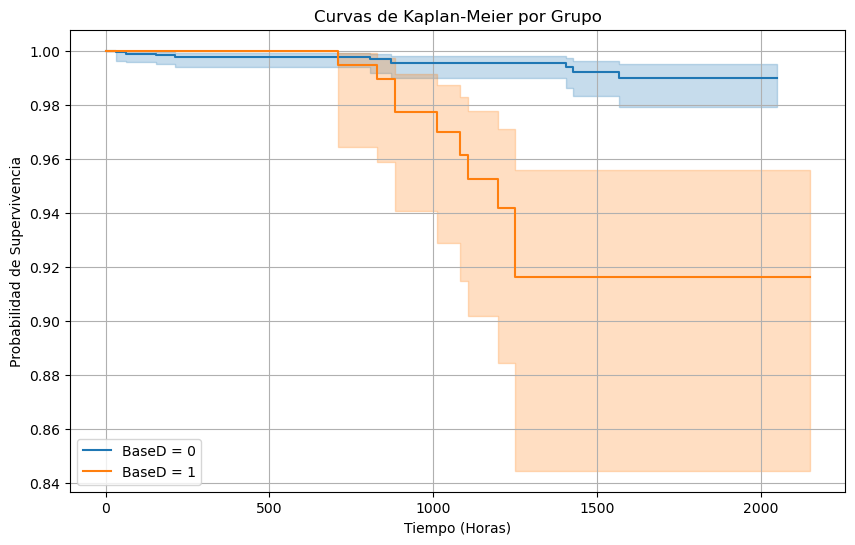

In [5]:
# Crear una figura
plt.figure(figsize=(10, 6))

# Ajustar y graficar para cada grupo
for grupo in [0, 1]:
    kmf = KaplanMeierFitter()
    mask = data_expanded['BaseD'] == grupo
    kmf.fit(durations=data_expanded[mask]['Hours'], event_observed=data_expanded[mask]['Status'], label=f'BaseD = {grupo}')
    kmf.plot_survival_function(ci_show=True)

plt.title('Curvas de Kaplan-Meier por Grupo')
plt.xlabel('Tiempo (Horas)')
plt.ylabel('Probabilidad de Supervivencia')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
result = logrank_test(
    data_expanded[data_expanded['BaseD'] == 0]['Hours'],
    data_expanded[data_expanded['BaseD'] == 1]['Hours'],
    event_observed_A=data_expanded[data_expanded['BaseD'] == 0]['Status'],
    event_observed_B=data_expanded[data_expanded['BaseD'] == 1]['Status']
)

print(f'Estadístico de Log-Rank: {result.test_statistic:.4f}')
print(f'Valor p: {result.p_value:.4f}')
result.p_value

Estadístico de Log-Rank: 29.9592
Valor p: 0.0000


4.412405827657969e-08

In [10]:
# Modelo Log-Normal
aft_lognormal = LogNormalAFTFitter()
aft_lognormal.fit(data_expanded, duration_col='Hours', event_col='Status', formula='BaseD')

# Modelo Weibull
aft_weibull = WeibullAFTFitter()
aft_weibull.fit(data_expanded, duration_col='Hours', event_col='Status', formula='BaseD')

print("\nResumen del modelo Log-Normal:")
aft_lognormal.print_summary()

# Mostrar resúmenes
print("Resumen del modelo Weibull:")
aft_weibull.print_summary()


# Comparar AIC
print("\nComparación de AIC:")
print(f"Weibull AIC: {aft_weibull.AIC_:.4f}")
print(f"Log-Normal AIC: {aft_lognormal.AIC_:.4f}")



Resumen del modelo Log-Normal:


<lifelines.LogNormalAFTFitter: fitted with 2256 total observations, 2237 right-censored observations>
             duration col = 'Hours'
                event col = 'Status'
   number of observations = 2256
number of events observed = 19
           log-likelihood = -231.95
         time fit was run = 2025-04-21 23:52:43 UTC

---
                   coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param  covariate                                                                                                         
mu_    Intercept  12.90   4.01e+05       1.13            10.68            15.12             43542.98             3.69e+06
       BaseD      -1.81       0.16       0.57            -2.92            -0.70                 0.05                 0.50
sigma_ Intercept   0.85       2.33       0.19             0.48             1.21                 1.62                 3.35

                   cmp to     z      p   -log2(p)
param  covariate                                 
mu_    Intercept     0.00 11.39 <0.005      97.46
       BaseD         0.00 -3.19 <0.005       9.44
sigma_ Intercept     0.00  4.56 <0.005      17.57
---
Concordance = 0.66
AIC = 469.90
log-likelihood ratio test = 14.99 on 1 df
-log2(p) of ll-ratio test = 13.18

Resumen del modelo Weibull:


<lifelines.WeibullAFTFitter: fitted with 2256 total observations, 2237 right-censored observations>
             duration col = 'Hours'
                event col = 'Status'
   number of observations = 2256
number of events observed = 19
           log-likelihood = -228.90
         time fit was run = 2025-04-21 23:52:44 UTC

---
                    coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ Intercept  10.90   54035.30       0.78             9.37            12.42             11757.95             2.48e+05
        BaseD      -1.60       0.20       0.45            -2.49            -0.71                 0.08                 0.49
rho_    Intercept   0.31       1.36       0.20            -0.09             0.70                 0.92                 2.02

                    cmp to     z      p   -log2(p)
param   covariate                                 
lambda_ Intercept     0.00 14.00 <0.005     145.62
        BaseD         0.00 -3.51 <0.005      11.13
rho_    Intercept     0.00  1.53   0.13       2.98
---
Concordance = 0.66
AIC = 463.79
log-likelihood ratio test = 19.53 on 1 df
-log2(p) of ll-ratio test = 16.62


Comparación de AIC:
Weibull AIC: 463.7912
Log-Normal AIC: 469.8969


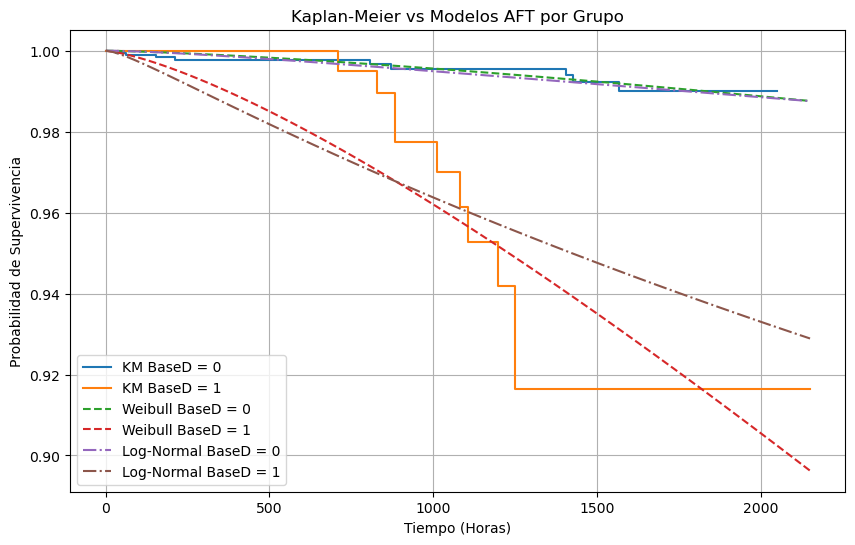

In [11]:
# Crear una figura
plt.figure(figsize=(10, 6))

# Ajustar y graficar Kaplan-Meier para cada grupo
for grupo in [0, 1]:
    kmf = KaplanMeierFitter()
    mask = data_expanded['BaseD'] == grupo
    kmf.fit(durations=data_expanded[mask]['Hours'], event_observed=data_expanded[mask]['Status'], label=f'KM BaseD = {grupo}')
    kmf.plot_survival_function(ci_show=False)

# Crear una secuencia de tiempo
t_seq = np.linspace(1, data_expanded['Hours'].max(), 100)

# Calcular y graficar curvas teóricas para cada modelo y grupo
for modelo, nombre_modelo in zip([aft_weibull, aft_lognormal], ['Weibull', 'Log-Normal']):
    for grupo in [0, 1]:
        df_pred = pd.DataFrame({'BaseD': [grupo]})
        surv_func = modelo.predict_survival_function(df_pred, times=t_seq)
        plt.plot(t_seq, surv_func.values.flatten(), linestyle='--' if nombre_modelo == 'Weibull' else '-.', label=f'{nombre_modelo} BaseD = {grupo}')

plt.title('Kaplan-Meier vs Modelos AFT por Grupo')
plt.xlabel('Tiempo (Horas)')
plt.ylabel('Probabilidad de Supervivencia')
plt.legend()
plt.grid(True)
plt.show()


In [41]:
from scipy.stats import chi2

# Modelos nulos
null_weibull = WeibullAFTFitter().fit(data_expanded.drop('BaseD', axis=1), duration_col="Hours", event_col="Status", formula= "")
null_normal = LogNormalAFTFitter().fit(data_expanded.drop('BaseD', axis=1), duration_col="Hours", event_col="Status")

# LRT
lrt_weibull = 2 * (aft_weibull.log_likelihood_ - null_weibull.log_likelihood_)
lrt_normal = 2 * (aft_lognormal.log_likelihood_ - null_normal.log_likelihood_)
print("LRT Weibull p-value:", chi2.sf(lrt_weibull, df=1))
print("LRT LogNormal p-value:", chi2.sf(lrt_normal, df=1))

# Wald (LogNormal)
beta = aft_lognormal.params_[1]
se = aft_lognormal.standard_errors_[1]
wald_stat = (beta / se)**2
print("Wald LogNormal p-value:", chi2.sf(wald_stat, df=1))

# Wald (Weibull)
beta = aft_weibull.params_[1]
se = aft_weibull.standard_errors_[1]
wald_stat = (beta / se)**2
print("Wald Weibull p-value:", chi2.sf(wald_stat, df=1))


LRT Weibull p-value: 9.904183465364546e-06
LRT LogNormal p-value: 0.00010803763921775347
Wald LogNormal p-value: 0.0014447095910178356
Wald Weibull p-value: 0.0004466472514273769


/var/folders/t_/smrw2q7d29j7w9fmzxnqx2_00000gn/T/ipykernel_24466/2420060866.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = aft_lognormal.params_[1]
/var/folders/t_/smrw2q7d29j7w9fmzxnqx2_00000gn/T/ipykernel_24466/2420060866.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  se = aft_lognormal.standard_errors_[1]
/var/folders/t_/smrw2q7d29j7w9fmzxnqx2_00000gn/T/ipykernel_24466/2420060866.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, 

/var/folders/t_/smrw2q7d29j7w9fmzxnqx2_00000gn/T/ipykernel_24466/1548623889.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  resids_normal = (np.log(data_expanded['Hours']) - lp_normal) / np.exp(aft_lognormal.params_["sigma_"][0])


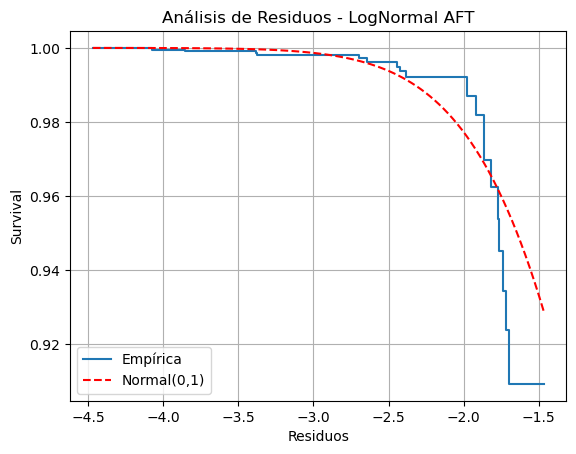

In [86]:
# Residuos para el modelo log-normal
lp_normal = np.log(aft_lognormal.predict_median(data_expanded))
resids_normal = (np.log(data_expanded['Hours']) - lp_normal) / np.exp(aft_lognormal.params_["sigma_"][0])

# KM de residuos
km_resid_normal = KaplanMeierFitter().fit(resids_normal, event_observed=data_expanded['Status'])

# Curva teórica
from scipy.stats import norm
x = np.linspace(min(resids_normal), max(resids_normal), 100)
y = 1 - norm.cdf(x)

# Plot
plt.step(km_resid_normal.survival_function_.index, km_resid_normal.survival_function_["KM_estimate"], label="Empírica")
plt.plot(x, y, 'r--', label="Normal(0,1)")
plt.title("Análisis de Residuos - LogNormal AFT")
plt.xlabel("Residuos")
plt.ylabel("Survival")
plt.legend()
plt.grid(True)
plt.show()


/var/folders/t_/smrw2q7d29j7w9fmzxnqx2_00000gn/T/ipykernel_24466/3766083456.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  resids_normal = (np.log(data_expanded['Hours']) - lp_normal) /np.exp(-aft_weibull.params_["rho_"][0])


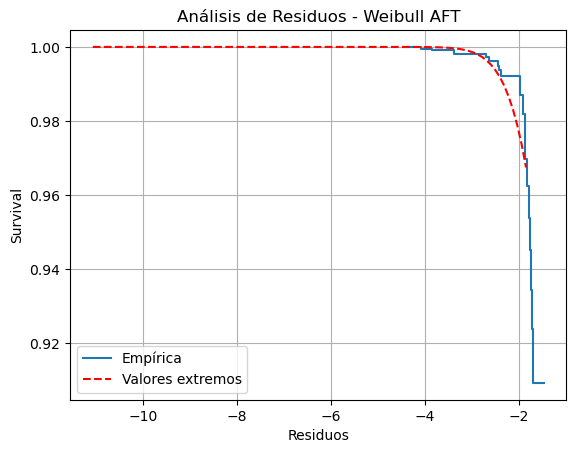

In [87]:

# Residuos para el modelo weibull
lp_normal = np.log(aft_weibull.predict_median(data_expanded))
resids_normal = (np.log(data_expanded['Hours']) - lp_normal) /np.exp(-aft_weibull.params_["rho_"][0])

# KM de residuos
km_resid_weibull = KaplanMeierFitter().fit(resids_normal, event_observed=data_expanded['Status'])

# Curva teórica
from scipy.stats import norm
x = np.linspace(min(resids_normal), max(resids_normal), 100)
y = 1 - norm.cdf(x)

# Plot
plt.step(km_resid_normal.survival_function_.index, km_resid_normal.survival_function_["KM_estimate"], label="Empírica")
plt.plot(x, y, 'r--', label="Valores extremos")
plt.title("Análisis de Residuos - Weibull AFT")
plt.xlabel("Residuos")
plt.ylabel("Survival")
plt.legend()
plt.grid(True)
plt.show()

/var/folders/t_/smrw2q7d29j7w9fmzxnqx2_00000gn/T/ipykernel_24466/486845217.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.exp(-aft_weibull.params_["rho_"][0])


0.7357106233544184